In [21]:
import os
import random
from dataclasses import dataclass
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

plt.style.use("default")
sns.set_theme(style="whitegrid")


In [22]:
@dataclass
class CFG:
    seed: int = 42
    data_root: Path = Path("./data")
    fronts_dir: Path = Path("./data/dvm_front/confirmed_fronts")

    image_size: int = 192
    batch_size: int = 128
    num_workers: int = 2

    train_split: float = 0.70
    val_split: float = 0.15
    test_split: float = 0.15

    epochs_scratch: int = 28
    epochs_pretrained: int = 16

    lr_scratch: float = 1e-3
    lr_pretrained: float = 3e-4
    weight_decay: float = 1e-4
    label_smoothing: float = 0.05

    freeze_epochs: int = 2
    patience: int = 6

    device: torch.device = torch.device(
        "mps" if torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
cfg = CFG()

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

seed_everything(cfg.seed)
print("device:", cfg.device)
print("torch:", torch.__version__)


device: mps
torch: 2.12.0


In [23]:
VALID_COLORS = {
    "black", "white", "silver", "grey", "blue",
    "red", "green", "brown", "beige",
    "orange", "yellow", "purple",
}

def load_front_views(fronts_dir: Path) -> pd.DataFrame:
    rows = []
    for img_path in fronts_dir.rglob("*"):
        if not img_path.is_file():
            continue
        if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue

        parts = img_path.name.split("$$")
        if len(parts) < 4:
            continue

        color = parts[3].strip().lower()
        if color not in VALID_COLORS:
            continue

        rows.append({
            "image_path": str(img_path),
            "color": color,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No images were loaded from {fronts_dir.resolve()}")

    return df

df = load_front_views(cfg.fronts_dir)
classes = sorted(df["color"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

df["label"] = df["color"].map(class_to_idx)

print("samples:", len(df))
print("classes:", classes)
print(df["color"].value_counts().to_string())


Exception ignored in: <function tqdm.__del__ at 0x118befb00>
Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/opt/homebrew/lib/python3.11/site-packages/tqdm/notebook.py", line 277, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


samples: 59410
classes: ['beige', 'black', 'blue', 'brown', 'green', 'grey', 'orange', 'purple', 'red', 'silver', 'white', 'yellow']
color
black     14317
grey       9474
white      9395
blue       8483
silver     7770
red        6095
brown       911
green       777
yellow      667
beige       600
orange      559
purple      362


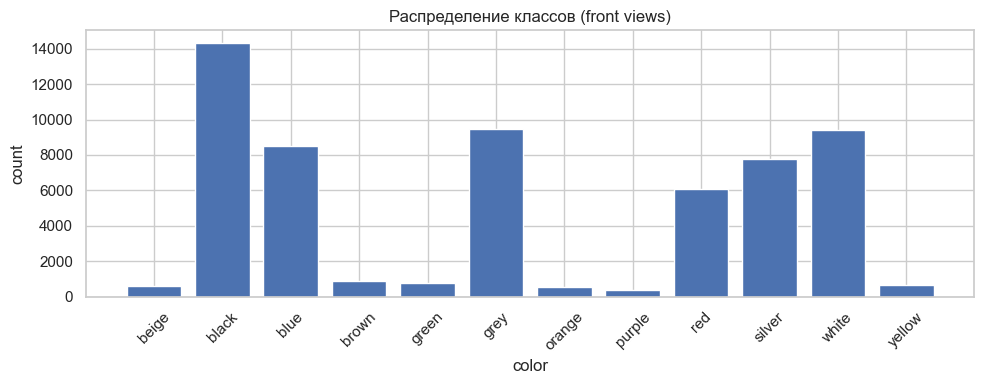

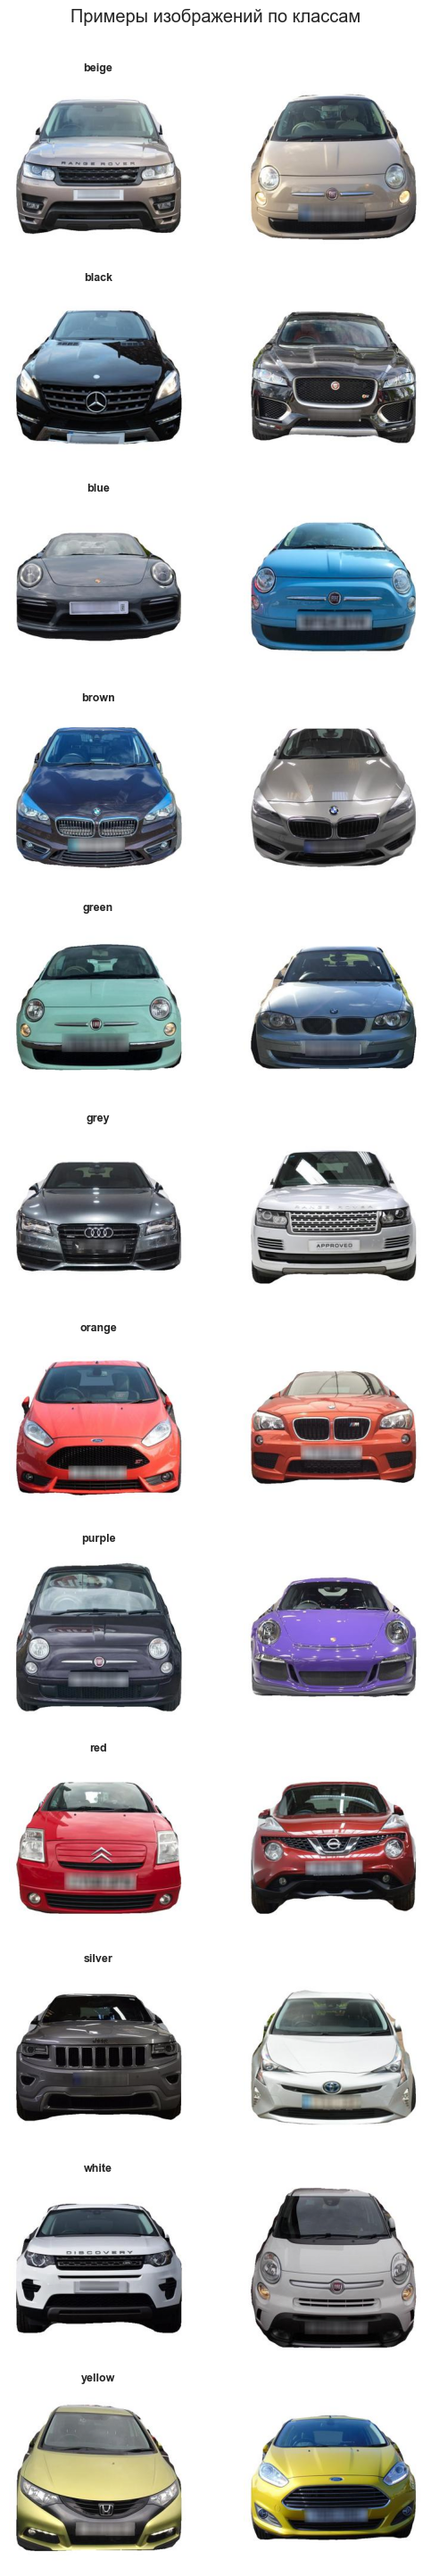

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
counts = df["color"].value_counts().reindex(classes)
ax.bar(counts.index, counts.values)
ax.set_title("Распределение классов (front views)")
ax.set_xlabel("color")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

def show_examples(frame: pd.DataFrame, n_per_class: int = 2) -> None:
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class * 3, len(classes) * 2.4))
    if n_per_class == 1:
        axes = np.expand_dims(axes, axis=1)

    for row_i, cls in enumerate(classes):
        subset = frame[frame["color"] == cls].sample(min(n_per_class, (frame["color"] == cls).sum()), random_state=cfg.seed)
        for col_i, (_, row) in enumerate(subset.iterrows()):
            ax = axes[row_i, col_i]
            try:
                img = Image.open(row["image_path"]).convert("RGB")
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "read error", ha="center", va="center")
            ax.axis("off")
            if col_i == 0:
                ax.set_title(cls, fontsize=9, fontweight="bold")

    plt.suptitle("Примеры изображений по классам", y=1.002)
    plt.tight_layout()
    plt.show()

show_examples(df, n_per_class=2)


In [25]:
train_df, temp_df = train_test_split(
    df,
    test_size=cfg.val_split + cfg.test_split,
    stratify=df["label"],
    random_state=cfg.seed,
)

val_size_relative = cfg.val_split / (cfg.val_split + cfg.test_split)

val_df, test_df = train_test_split(
    temp_df,
    test_size=1.0 - val_size_relative,
    stratify=temp_df["label"],
    random_state=cfg.seed,
)

print(f"train: {len(train_df)}")
print(f"val:   {len(val_df)}")
print(f"test:  {len(test_df)}")

train_counts = np.bincount(train_df["label"].values, minlength=len(classes))
sample_weights = 1.0 / (train_counts[train_df["label"].values] + 1e-6)
sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(train_df),
    replacement=True,
)


train: 41587
val:   8911
test:  8912


In [26]:
from cars_loader import CarColorDataset

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((cfg.image_size + 32, cfg.image_size + 32)),
    transforms.RandomResizedCrop(cfg.image_size, scale=(0.78, 1.0), ratio=(0.92, 1.08)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.3, 3.3), value="random"),
])

eval_tf = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

train_loader = DataLoader(
    CarColorDataset(train_df, train_tf),
    batch_size=cfg.batch_size,
    sampler=sampler,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    CarColorDataset(val_df, eval_tf),
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    CarColorDataset(test_df, eval_tf),
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

print("loaders are ready")


loaders are ready


In [27]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.relu(x + residual)
        return x


class ResNet18Scratch(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = self._make_layer(64, blocks=2, stride=1)
        self.layer2 = self._make_layer(128, blocks=2, stride=2)
        self.layer3 = self._make_layer(256, blocks=2, stride=2)
        self.layer4 = self._make_layer(512, blocks=2, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.25)
        self.fc = nn.Linear(512, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def _make_layer(self, out_channels: int, blocks: int, stride: int):
        layers = [BasicBlock(self.in_channels, out_channels, stride=stride)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


scratch_model = ResNet18Scratch(num_classes=len(classes)).to(cfg.device)
print("scratch params:", sum(p.numel() for p in scratch_model.parameters()))


scratch params: 11182668


In [28]:
def make_resnet50(num_classes: int):
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )
    return model

def make_efficientnet_b0(num_classes: int):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

pretrained_resnet50 = make_resnet50(len(classes)).to(cfg.device)
pretrained_effnet = make_efficientnet_b0(len(classes)).to(cfg.device)

print("resnet50 params:", sum(p.numel() for p in pretrained_resnet50.parameters()))
print("efficientnet params:", sum(p.numel() for p in pretrained_effnet.parameters()))


resnet50 params: 23532620
efficientnet params: 4022920


In [29]:
def toggle_backbone(model: nn.Module, trainable: bool) -> None:
    for name, param in model.named_parameters():
        if name.startswith("fc.") or name.startswith("classifier."):
            continue
        param.requires_grad = trainable

def build_optimizer(model: nn.Module, lr: float, weight_decay: float):
    return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

def move_batch(batch):
    x, y = batch
    return x.to(cfg.device, non_blocking=True), y.to(cfg.device, non_blocking=True)

@torch.no_grad()
def run_eval(model: nn.Module, loader: DataLoader, criterion):
    model.eval()
    total_loss = 0.0
    all_pred = []
    all_true = []

    for x, y in tqdm(loader, leave=False, desc="eval"):
        x, y = move_batch((x, y))
        with torch.autocast(device_type=cfg.device.type, enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        all_pred.extend(logits.argmax(dim=1).cpu().tolist())
        all_true.extend(y.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    acc = (np.array(all_true) == np.array(all_pred)).mean()

    return {
        "loss": avg_loss,
        "acc": acc,
        "f1_macro": f1,
        "preds": all_pred,
        "targets": all_true,
    }

def run_train(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
              epochs: int, lr: float, weight_decay: float,
              label_smoothing: float, patience: int, freeze_epochs: int = 0,
              model_name: str = "model"):

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = build_optimizer(model, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_state = deepcopy(model.state_dict())
    best_f1 = -1.0
    bad_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        if freeze_epochs > 0:
            toggle_backbone(model, trainable=(epoch > freeze_epochs))

        model.train()
        train_loss = 0.0
        train_true = []
        train_pred = []

        for x, y in tqdm(train_loader, desc=f"{model_name} | epoch {epoch}/{epochs}", leave=False):
            x, y = move_batch((x, y))
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type=cfg.device.type, enabled=torch.cuda.is_available()):
                logits = model(x)
                loss = criterion(logits, y)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            train_pred.extend(logits.argmax(dim=1).detach().cpu().tolist())
            train_true.extend(y.detach().cpu().tolist())

        scheduler.step()

        train_loss /= len(train_loader.dataset)
        train_acc = (np.array(train_true) == np.array(train_pred)).mean()
        train_f1 = f1_score(train_true, train_pred, average="macro", zero_division=0)

        val_metrics = run_eval(model, val_loader, criterion)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1_macro"],
        }
        history.append(row)

        print(
            f"{model_name:28s} | "
            f"epoch {epoch:02d} | "
            f"train_f1={train_f1:.4f} | "
            f"val_f1={val_metrics['f1_macro']:.4f} | "
            f"val_acc={val_metrics['acc']:.4f}"
        )

        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            best_state = deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print(f"{model_name}: early stopping")
            break

    model.load_state_dict(best_state)
    return history


In [30]:
scratch_history = run_train(
    scratch_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.epochs_scratch,
    lr=cfg.lr_scratch,
    weight_decay=cfg.weight_decay,
    label_smoothing=cfg.label_smoothing,
    patience=cfg.patience,
    freeze_epochs=0,
    model_name="Resnet18 Scratch",
)

resnet50_history = run_train(
    pretrained_resnet50,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.epochs_pretrained,
    lr=cfg.lr_pretrained,
    weight_decay=cfg.weight_decay,
    label_smoothing=cfg.label_smoothing,
    patience=cfg.patience,
    freeze_epochs=cfg.freeze_epochs,
    model_name="ResNet50 (pretrained)",
)

effnet_history = run_train(
    pretrained_effnet,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.epochs_pretrained,
    lr=cfg.lr_pretrained,
    weight_decay=cfg.weight_decay,
    label_smoothing=cfg.label_smoothing,
    patience=cfg.patience,
    freeze_epochs=cfg.freeze_epochs,
    model_name="EfficientNet-B0 (pretrained)",
)


Resnet18 Scratch | epoch 1/28:   0%|          | 0/325 [00:03<?, ?it/s]

eval:   0%|          | 0/70 [00:02<?, ?it/s]

Resnet18 Scratch             | epoch 01 | train_f1=0.6088 | val_f1=0.5873 | val_acc=0.6842


Resnet18 Scratch | epoch 2/28:   0%|          | 0/325 [00:02<?, ?it/s]

eval:   0%|          | 0/70 [00:02<?, ?it/s]

...

eval:   0%|          | 0/70 [00:02<?, ?it/s]

EfficientNet-B0 (pretrained) | epoch 15 | train_f1=0.9878 | val_f1=0.8872 | val_acc=0.9318


EfficientNet-B0 (pretrained) | epoch 16/16:   0%|          | 0/325 [00:02<?, ?it/s]

eval:   0%|          | 0/70 [00:02<?, ?it/s]

EfficientNet-B0 (pretrained) | epoch 16 | train_f1=0.9874 | val_f1=0.8905 | val_acc=0.9341


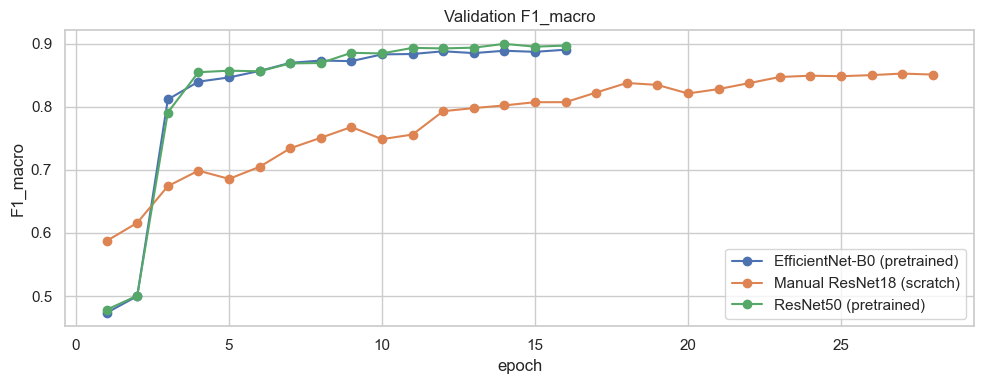

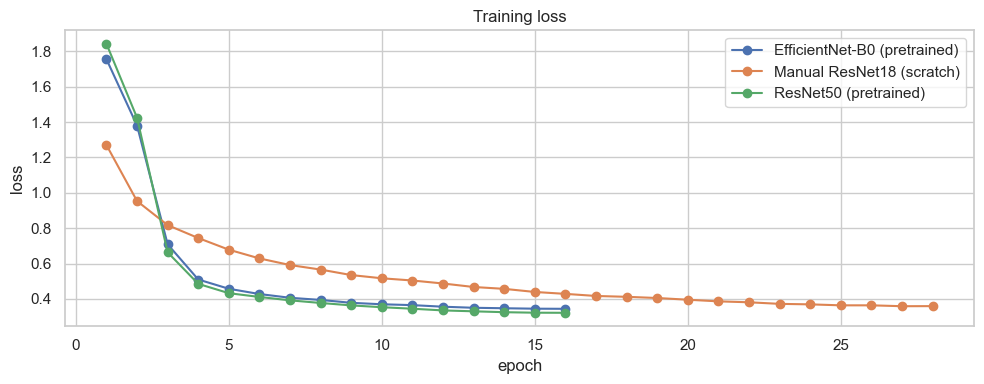

In [34]:
def history_to_df(history, model_name: str) -> pd.DataFrame:
    df_hist = pd.DataFrame(history)
    df_hist["model"] = model_name
    return df_hist

hist_df = pd.concat([
    history_to_df(scratch_history, "Manual ResNet18 (scratch)"),
    history_to_df(resnet50_history, "ResNet50 (pretrained)"),
    history_to_df(effnet_history, "EfficientNet-B0 (pretrained)"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 4))
for name, group in hist_df.groupby("model"):
    ax.plot(group["epoch"], group["val_f1"], marker="o", label=name)
ax.set_title("Validation F1_macro")
ax.set_xlabel("epoch")
ax.set_ylabel("F1_macro")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
for name, group in hist_df.groupby("model"):
    ax.plot(group["epoch"], group["train_loss"], marker="o", label=name)
ax.set_title("Training loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
plt.tight_layout()
plt.show()


In [35]:
criterion = nn.CrossEntropyLoss()

models_map = {
    "Manual ResNet18 (scratch)": scratch_model,
    "ResNet50 (pretrained)": pretrained_resnet50,
    "EfficientNet-B0 (pretrained)": pretrained_effnet,
}

results = {}
for name, model in models_map.items():
    metrics = run_eval(model, test_loader, criterion)
    results[name] = metrics
    print(f"{name:28s} | acc={metrics['acc']:.4f} | f1_macro={metrics['f1_macro']:.4f}")

summary = pd.DataFrame([
    {
        "Model": name,
        "Accuracy": metrics["acc"],
        "F1_macro": metrics["f1_macro"],
        "Pass_0.8": metrics["f1_macro"] >= 0.8,
    }
    for name, metrics in results.items()
]).sort_values("F1_macro", ascending=False)

summary


eval:   0%|          | 0/70 [00:02<?, ?it/s]

Manual ResNet18 (scratch)    | acc=0.9065 | f1_macro=0.8523


eval:   0%|          | 0/70 [00:02<?, ?it/s]

ResNet50 (pretrained)        | acc=0.9390 | f1_macro=0.8930


eval:   0%|          | 0/70 [00:02<?, ?it/s]

EfficientNet-B0 (pretrained) | acc=0.9339 | f1_macro=0.8889


,Model,Accuracy,F1_macro,Pass_0.8
1,ResNet50 (pretrained),0.938959,0.892983,True
2,EfficientNet-B0 (pretrained),0.933909,0.888908,True
0,Manual ResNet18 (scratch),0.906531,0.852324,True


Best model: ResNet50 (pretrained)
              precision    recall  f1-score   support

       beige     0.8690    0.8111    0.8391        90
       black     0.9404    0.9693    0.9546      2148
        blue     0.9594    0.9097    0.9339      1273
       brown     0.8293    0.7500    0.7876       136
       green     0.9327    0.8362    0.8818       116
        grey     0.8892    0.9092    0.8991      1421
      orange     0.9028    0.7738    0.8333        84
      purple     0.7500    0.7222    0.7358        54
         red     0.9761    0.9825    0.9793       915
      silver     0.9229    0.9245    0.9237      1166
       white     0.9809    0.9837    0.9823      1409
      yellow     0.9604    0.9700    0.9652       100

    accuracy                         0.9390      8912
   macro avg     0.9094    0.8785    0.8930      8912
weighted avg     0.9389    0.9390    0.9387      8912



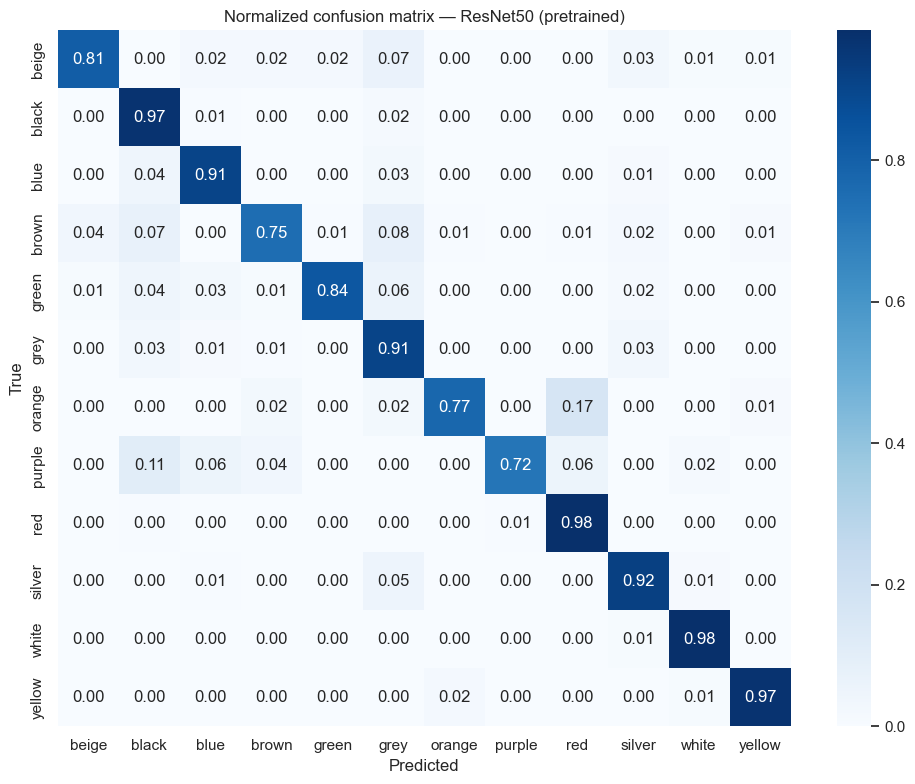

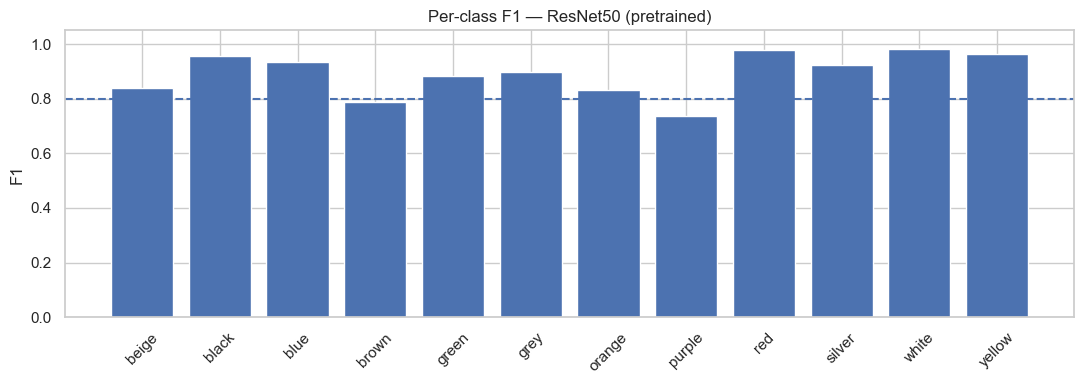

In [33]:
best_name = summary.iloc[0]["Model"]
best_metrics = results[best_name]
best_model = models_map[best_name]

print("Best model:", best_name)
print(
    classification_report(
        best_metrics["targets"],
        best_metrics["preds"],
        target_names=classes,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(best_metrics["targets"], best_metrics["preds"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=ax,
)
ax.set_title(f"Normalized confusion matrix — {best_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

f1_per_class = f1_score(
    best_metrics["targets"],
    best_metrics["preds"],
    average=None,
    labels=list(range(len(classes))),
    zero_division=0,
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(classes, f1_per_class)
ax.axhline(0.8, linestyle="--")
ax.set_ylim(0, 1.05)
ax.set_title(f"Per-class F1 — {best_name}")
ax.set_ylabel("F1")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
